# 02 · Rede densa em Keras

A mesma ideia do notebook 01, agora em **Keras 3 (TensorFlow)**, seguindo a receita dos
exercícios de câncer de mama e crédito alemão:

* camadas `Dense` + ReLU com **Dropout** entre elas;
* saída **sigmoide** = P(doença cardiovascular);
* perda de **entropia cruzada binária** e otimizador **Adam**;
* **EarlyStopping** pela AUC de validação, restaurando os melhores pesos;
* **class_weight**, caso as classes estejam desbalanceadas;
* **limiar de decisão** escolhido na validação, pensando em triagem — e não fixo em 0,5.

O conjunto de teste só é usado no fim, uma única vez.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.dados import preparar
from src.model import avaliacao, mlp_keras
from src.utils import graficos
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "02-mlp-keras"

## 1. Dados

Divisão estratificada 60 / 20 / 20. O pré-processador (padronização + one-hot) é ajustado
**somente no treino**.

In [2]:
particao = preparar()
resumo = pd.DataFrame({
    "pacientes": [len(particao.y_treino), len(particao.y_val), len(particao.y_teste)],
    "com_doenca": [particao.y_treino.mean(), particao.y_val.mean(), particao.y_teste.mean()],
}, index=["treino", "validação", "teste"])
print("Entradas da rede:", particao.nomes)
resumo

Entradas da rede: ['idade_anos', 'height', 'weight', 'imc', 'ap_hi', 'ap_lo', 'cholesterol_1', 'cholesterol_2', 'cholesterol_3', 'gluc_1', 'gluc_2', 'gluc_3', 'sexo_masculino', 'smoke', 'alco', 'active']


,pacientes,com_doenca
treino,41130,0.494797
validação,13710,0.494748
teste,13711,0.494785


As classes estão praticamente **equilibradas** (≈ 49 % com doença), então o
`class_weight` calculado fica perto de 1 para as duas classes e quase não altera o treino.
Ele é mantido no código porque, se a base mudar (por exemplo, só pacientes jovens, com
prevalência menor), passa a fazer diferença.

In [3]:
pesos = mlp_keras.pesos_de_classe(particao.y_treino)
print("Pesos de classe:", {k: round(v, 3) for k, v in pesos.items()})

Pesos de classe: {0: 1.0, 1: 1.021}


## 2. Arquitetura

In [4]:
modelo = mlp_keras.construir_mlp(particao.n_entradas, ocultas=(64, 32, 16), dropout=0.2)
modelo.summary()

Model: "mlp_cardio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treino

Épocas executadas: 53


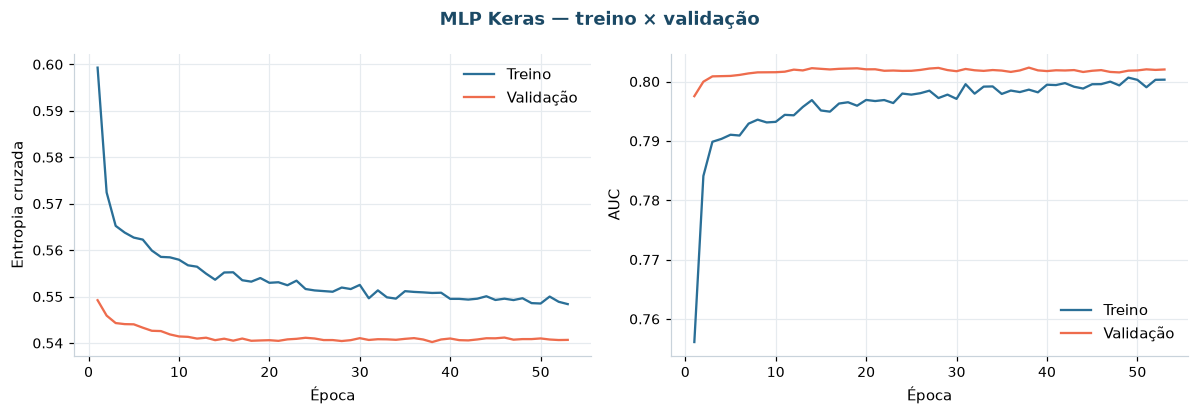

In [5]:
historico = mlp_keras.treinar(
    modelo,
    particao.X_treino, particao.y_treino,
    particao.X_val, particao.y_val,
    epocas=200, lote=256, paciencia=15,
    class_weight=pesos,
)
print(f"Épocas executadas: {len(historico.history['loss'])}")

fig, dados = graficos.curvas_de_treino(historico.history, "MLP Keras — treino × validação")
salvar_figura(fig, SECAO, "curvas-treino", dados)
plt.show()

A perda de validação acompanha a de treino, sem abrir uma distância grande entre elas:
com Dropout e parada antecipada, a rede não está decorando os pacientes do treino.

## 4. Escolha do limiar de decisão

Em triagem, deixar passar um paciente doente (**falso negativo**) é pior do que chamar
para exame alguém saudável (**falso positivo**). A regra adotada: usar o **maior limiar
que ainda encontre pelo menos 80 % dos doentes** na validação.

Limiar escolhido na validação: 0.380


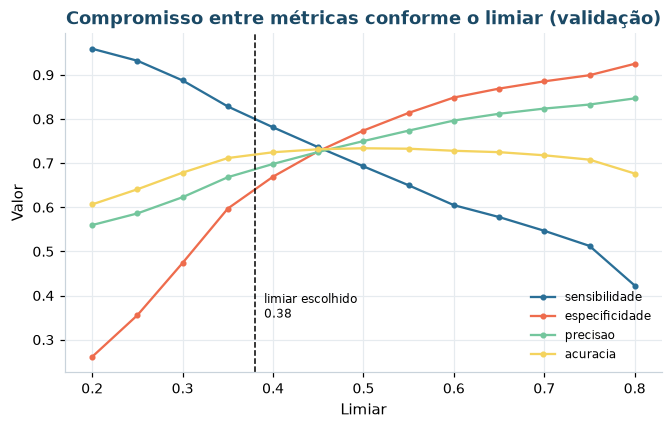

,sensibilidade,especificidade,precisao,acuracia
limiar,,,,
0.20,0.959163,0.261441,0.559800,0.606637
0.25,0.932036,0.355710,0.586185,0.640846
0.30,0.887365,0.474087,0.622956,0.678556
0.35,0.828395,0.597228,0.668213,0.711597
0.40,0.781218,0.669410,0.698247,0.724726
0.45,0.736105,0.727010,0.725305,0.731510
0.50,0.692761,0.773928,0.750040,0.733771
0.55,0.649860,0.813917,0.773741,0.732750
0.60,0.604895,0.848708,0.796544,0.728082


In [6]:
p_val = mlp_keras.prever(modelo, particao.X_val)
limiar = avaliacao.escolher_limiar(particao.y_val, p_val, config.RECALL_MINIMO)
print(f"Limiar escolhido na validação: {limiar:.3f}")

grade = np.round(np.arange(0.20, 0.81, 0.05), 2)
varredura = pd.DataFrame(
    [avaliacao.metricas(particao.y_val, p_val, l) for l in grade]
).set_index("limiar")[["sensibilidade", "especificidade", "precisao", "acuracia"]]

fig, eixo = plt.subplots(figsize=(7, 4))
for coluna, cor in zip(varredura.columns, config.PALETA):
    eixo.plot(varredura.index, varredura[coluna], marker="o", markersize=3, label=coluna, color=cor)
eixo.axvline(limiar, color="black", linestyle="--", linewidth=1)
eixo.text(limiar + 0.01, 0.35, f"limiar escolhido\n{limiar:.2f}", fontsize=8)
eixo.set(title="Compromisso entre métricas conforme o limiar (validação)", xlabel="Limiar", ylabel="Valor")
eixo.legend(fontsize=8)
salvar_figura(fig, SECAO, "varredura-limiar", varredura)
plt.show()
varredura

## 5. Avaliação final no teste

In [7]:
p_teste = mlp_keras.prever(modelo, particao.X_teste)
resultados = {
    "MLP Keras · limiar 0,50": avaliacao.metricas(particao.y_teste, p_teste, 0.5),
    f"MLP Keras · limiar {limiar:.2f}".replace(".", ","): avaliacao.metricas(particao.y_teste, p_teste, limiar),
}
tabela = avaliacao.tabela_comparativa(resultados)
salvar_tabela(tabela, SECAO, "metricas-teste")
tabela

,auc_roc,auc_pr,acuracia,sensibilidade,especificidade,precisao,f1,brier,limiar
"MLP Keras · limiar 0,50",0.8005,0.7798,0.7369,0.7005,0.7725,0.7509,0.7248,0.1805,0.5000
"MLP Keras · limiar 0,38",0.8005,0.7798,0.7156,0.8075,0.6257,0.6787,0.7375,0.1805,0.3801


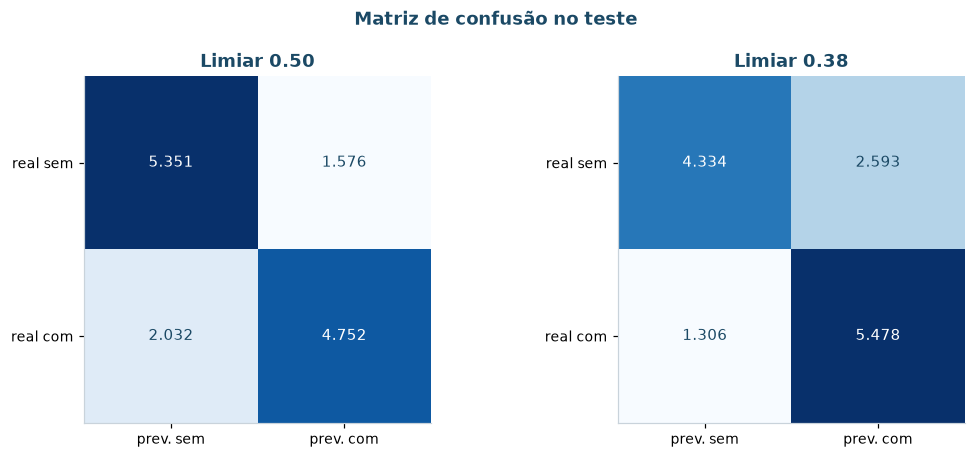

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4.2))
for eixo, l in zip(eixos, [0.5, limiar]):
    f, cm = graficos.matriz_confusao(particao.y_teste, p_teste, l, "Teste")
    plt.close(f)
    eixo.imshow(cm.to_numpy(), cmap="Blues")
    eixo.grid(False)
    for i in range(2):
        for j in range(2):
            eixo.text(j, i, f"{cm.iat[i, j]:,}".replace(",", "."), ha="center", va="center",
                      color="white" if cm.iat[i, j] > cm.to_numpy().max() / 2 else config.AZUL_PROFUNDO)
    eixo.set_xticks([0, 1], ["prev. sem", "prev. com"])
    eixo.set_yticks([0, 1], ["real sem", "real com"])
    eixo.set_title(f"Limiar {l:.2f}")
fig.suptitle("Matriz de confusão no teste", fontweight="bold", color=config.AZUL_PROFUNDO)
fig.tight_layout()
salvar_figura(fig, SECAO, "matriz-confusao-teste", cm)
plt.show()

## 6. Um paciente novo

A rede recebe as variáveis na escala original; o pré-processador ajustado no treino faz a
padronização e o one-hot antes da previsão.

In [9]:
from src.data.dados import derivar_variaveis

novo = derivar_variaveis(pd.DataFrame([{
    "gender": 2, "height": 172, "weight": 94, "ap_hi": 150, "ap_lo": 95,
    "cholesterol": 2, "gluc": 1, "smoke": 1, "alco": 0, "active": 0, "idade_anos": 58,
}]))
X_novo = particao.preprocessador.transform(novo[config.ENTRADAS]).astype("float32")
prob = mlp_keras.prever(modelo, X_novo)[0]
print(f"P(doença cardiovascular) = {prob:.1%}")
print("Encaminhar para investigação" if prob >= limiar else "Acompanhamento de rotina")

P(doença cardiovascular) = 87.6%
Encaminhar para investigação


## Conclusões

* A rede atinge AUC ≈ 0,80 no teste. O teto é limitado pelo ruído nos rótulos e pela
  ausência de exames como ECG — o notebook 05 mostra que modelos clássicos param no mesmo
  lugar.
* Treino e validação caminham juntos: não há sobreajuste relevante.
* Com o limiar ajustado para triagem (≈ 0,38), a rede encontra ≈ 81 % dos doentes, contra
  ≈ 70 % no limiar 0,5 — ao custo de a especificidade cair de ≈ 77 % para ≈ 63 %. É uma
  decisão de negócio, não de modelagem — a varredura acima mostra o preço de cada ponto.